<a href="https://colab.research.google.com/github/sthefanecosta/telecom-x-churn-analysis/blob/main/Analise_Evasao_TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests
import io



In [6]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'

In [13]:
dados_api = requests.get(url).json()
df_final = pd.json_normalize(dados_api)

In [14]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [15]:
df_final['account.Charges.Total'] = pd.to_numeric(df_final['account.Charges.Total'], errors='coerce')

In [16]:
df_final['account.Charges.Total'] = df_final['account.Charges.Total'].fillna(0)

In [17]:
colunas_relevantes = [
    'Churn',
    'customer.gender',
    'customer.tenure',
    'account.Contract',
    'account.Charges.Monthly',
    'account.Charges.Total'
]

display(df_final[colunas_relevantes].head())

,Churn,customer.gender,customer.tenure,account.Contract,account.Charges.Monthly,account.Charges.Total
0,No,Female,9,One year,65.6,593.30
1,No,Male,9,Month-to-month,59.9,542.40
2,Yes,Male,4,Month-to-month,73.9,280.85
3,Yes,Male,13,Month-to-month,98.0,1237.85
4,Yes,Female,3,Month-to-month,83.9,267.40


In [18]:
total_antes = len(df_final)
df_final = df_final.drop_duplicates()
total_depois = len(df_final)

print(f"Limpeza de duplicatas: {total_antes - total_depois} linhas removidas.")

Limpeza de duplicatas: 0 linhas removidas.


In [19]:
analise_tempo = df_final.groupby('Churn')['customer.tenure'].mean()

print("Média de meses de permanência:")
print(analise_tempo)

Média de meses de permanência:
Churn
       31.571429
No     37.569965
Yes    17.979133
Name: customer.tenure, dtype: float64


In [20]:
cruzamento = pd.crosstab(df_final['account.Contract'], df_final['Churn'], normalize='index') * 100

print("Porcentagem de Churn por tipo de contrato:")
print(cruzamento)

Porcentagem de Churn por tipo de contrato:
Churn                              No        Yes
account.Contract                                
Month-to-month    3.245943  55.430712  41.323346
One year          3.028308  86.043450  10.928242
Two year          2.753873  94.492255   2.753873


In [21]:
gastos = df_final.groupby('Churn')['account.Charges.Monthly'].mean()

print("Média de gastos mensais:")
print(gastos)

Média de gastos mensais:
Churn
       63.412277
No     61.265124
Yes    74.441332
Name: account.Charges.Monthly, dtype: float64


In [22]:
df_final['Contas_Diarias'] = df_final['account.Charges.Monthly'] / 30
df_final[['account.Charges.Monthly', 'Contas_Diarias']].head()

,account.Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [23]:
df_final['Churn_Binario'] = df_final['Churn'].map({'Yes': 1, 'No': 0})

In [24]:
df_final = df_final.rename(columns={
    'customer.gender': 'Genero',
    'customer.tenure': 'Tempo_Permanencia',
    'account.Contract': 'Tipo_Contrato',
    'account.Charges.Monthly': 'Gasto_Mensal'
})

print(df_final[['Churn_Binario', 'Genero', 'Tempo_Permanencia', 'Tipo_Contrato', 'Gasto_Mensal']].head())

   Churn_Binario  Genero  Tempo_Permanencia   Tipo_Contrato  Gasto_Mensal
0            0.0  Female                  9        One year          65.6
1            0.0    Male                  9  Month-to-month          59.9
2            1.0    Male                  4  Month-to-month          73.9
3            1.0    Male                 13  Month-to-month          98.0
4            1.0  Female                  3  Month-to-month          83.9


In [27]:
estatisticas = df_final[['Tempo_Permanencia', 'Gasto_Mensal', 'Contas_Diarias']].describe()
print(estatisticas)

       Tempo_Permanencia  Gasto_Mensal  Contas_Diarias
count        7267.000000   7267.000000     7267.000000
mean           32.346498     64.720098        2.157337
std            24.571773     30.129572        1.004319
min             0.000000     18.250000        0.608333
25%             9.000000     35.425000        1.180833
50%            29.000000     70.300000        2.343333
75%            55.000000     89.875000        2.995833
max            72.000000    118.750000        3.958333


In [28]:
import matplotlib.pyplot as plt

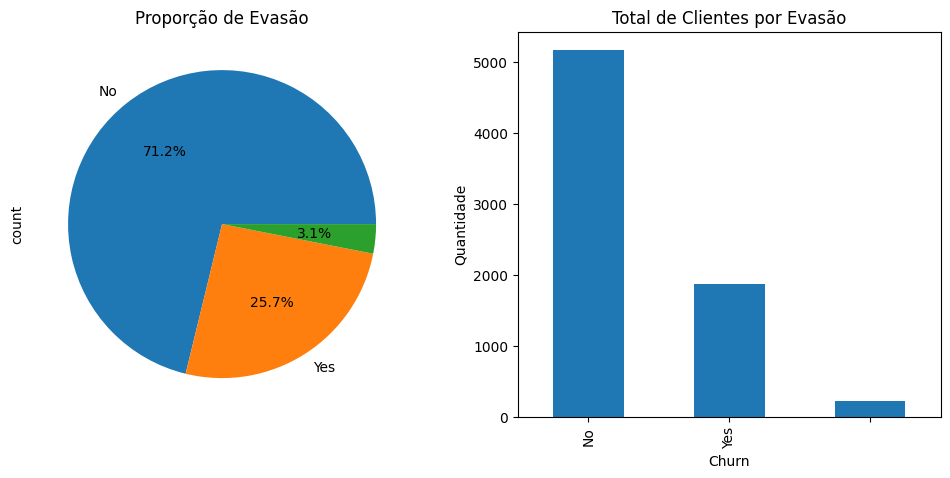

In [29]:
ig, ax = plt.subplots(1, 2, figsize=(12, 5))

df_final['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Proporção de Evasão')

df_final['Churn'].value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title('Total de Clientes por Evasão')
ax[1].set_ylabel('Quantidade')

plt.show()

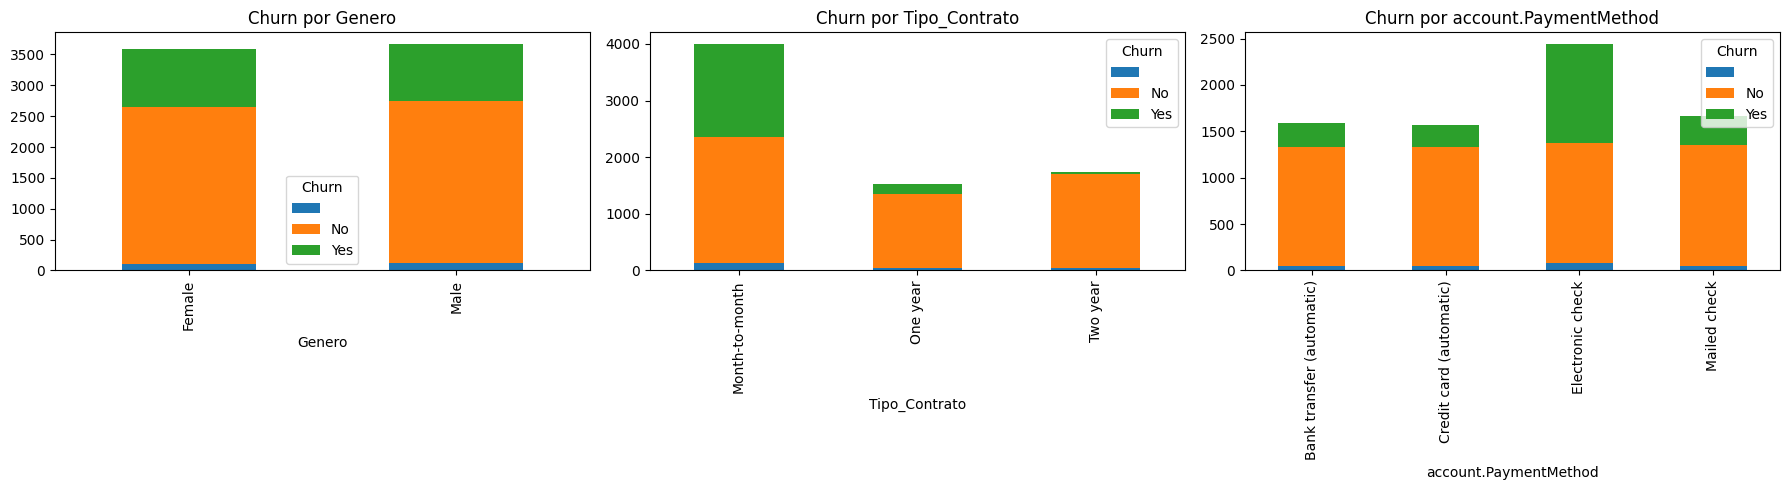

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colunas = ['Genero', 'Tipo_Contrato', 'account.PaymentMethod']

for i, col in enumerate(colunas):
    pd.crosstab(df_final[col], df_final['Churn']).plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'Churn por {col}')

plt.tight_layout()
plt.show()

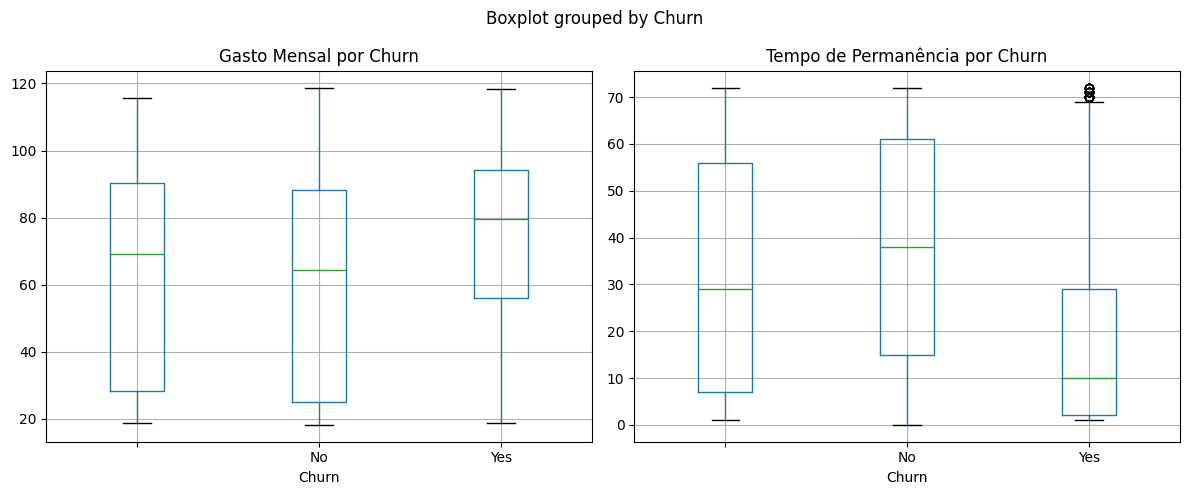

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_final.boxplot(column='Gasto_Mensal', by='Churn', ax=axes[0])
axes[0].set_title('Gasto Mensal por Churn')

df_final.boxplot(column='Tempo_Permanencia', by='Churn', ax=axes[1])
axes[1].set_title('Tempo de Permanência por Churn')

plt.tight_layout()
plt.show()

# **1. Objetivo**
*Identificar os motivos pelos quais os clientes cancelam o serviço e propor estratégias para aumentar sua permanência.*

# **2. Metodologia**
- **Limpeza:** Estruturamos a base de dados, eliminamos duplicatas e padronizamos a informação.  
- **Transformação:** Convertemos variáveis em formatos numéricos, ajustamos nomes de colunas para melhor legibilidade e criamos a métrica "Custo Diário" para detalhar o consumo.  
- **Análise:** Exploramos o perfil dos clientes que cancelaram, considerando tempo de permanência, tipo de contrato e valor mensal pago.  

# **3. Principais Descobertas**
- Contratos mensais apresentam maior probabilidade de cancelamento.  
- Clientes que abandonam o serviço permanecem, em média, 18 meses, enquanto os que permanecem têm uma média de 38 meses.  
- O gasto mensal médio de quem cancela é mais alto do que o dos clientes fidelizados.  

# **4. Conclusões e Recomendações**
A empresa enfrenta maior evasão no início do relacionamento e em contratos mais curtos.  
Recomendações:  
- Implementar programas de fidelização que incentivem a adesão a contratos anuais.  
- Oferecer acompanhamento dedicado nos primeiros meses para garantir maior engajamento e reduzir a percepção de alto custo em relação ao benefício.